# Shapash - Recourse and What-If Simulation

This notebook shows how to simulate changes on an individual (what-if) and measure their impact on prediction and local contributions.

In [ ]:
import numpy as np
import pandas as pd

from category_encoders import one_hot
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading

## 1. Load data and train a baseline model

In [ ]:
house_df, house_dict = data_loading("house_prices")

target_name = "SalePrice"
X_raw = house_df.drop(columns=[target_name]).copy()
y = house_df[[target_name]]

categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X_raw.columns if c not in categorical_cols]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42
)

num_fill_values = X_train_raw[numeric_cols].median()
cat_fill_values = X_train_raw[categorical_cols].mode(dropna=True).iloc[0]

X_train_ready = X_train_raw.copy()
X_test_ready = X_test_raw.copy()
X_train_ready[numeric_cols] = X_train_ready[numeric_cols].fillna(num_fill_values)
X_test_ready[numeric_cols] = X_test_ready[numeric_cols].fillna(num_fill_values)
X_train_ready[categorical_cols] = X_train_ready[categorical_cols].fillna(cat_fill_values)
X_test_ready[categorical_cols] = X_test_ready[categorical_cols].fillna(cat_fill_values)

preprocessing = one_hot.OneHotEncoder(cols=categorical_cols)
X_train = preprocessing.fit_transform(X_train_ready)
X_test = preprocessing.transform(X_test_ready)

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train.iloc[:, 0])

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

metrics = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_train.iloc[:, 0], pred_train),
            mean_absolute_error(y_test.iloc[:, 0], pred_test),
        ],
        "R2": [
            r2_score(y_train.iloc[:, 0], pred_train),
            r2_score(y_test.iloc[:, 0], pred_test),
        ],
    },
    index=["train", "test"],
)
metrics

,MAE,R2
train,6608.674548,0.978756
test,16927.454356,0.893307


## 2. Compile a SmartExplainer for local explanations

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x10d059b20>


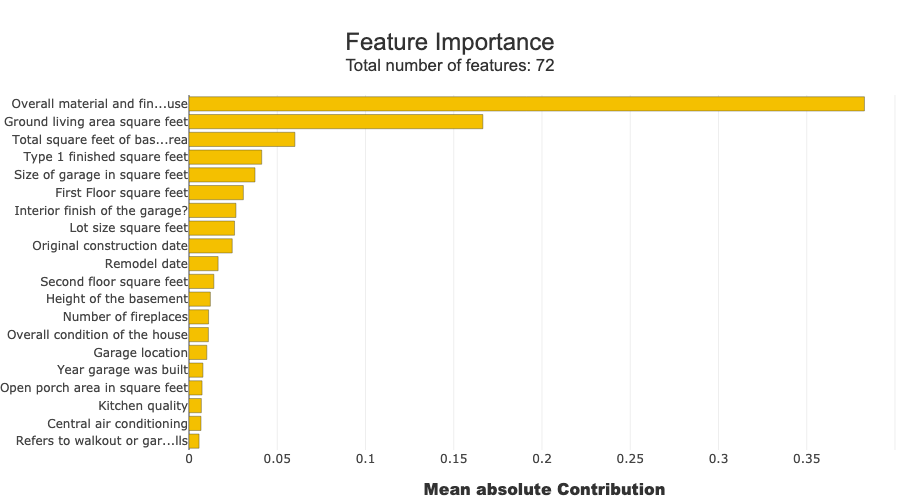

In [3]:
xpl = SmartExplainer(
    model=model,
    preprocessing=preprocessing,
    features_dict=house_dict,
    title_story="House prices - what-if recourse",
)

y_pred_test_df = pd.DataFrame(pred_test, index=X_test_raw.index, columns=[target_name])

xpl.compile(
    x=X_test,
    y_pred=y_pred_test_df,
    y_target=y_test,
    additional_data=X_test_ready,
)

xpl.plot.features_importance()

## 3. Select one individual to improve

In [4]:
base_idx = y_pred_test_df[target_name].idxmin()
base_row = X_test_ready.loc[[base_idx]].copy()
base_pred = float(model.predict(preprocessing.transform(base_row))[0])

base_row.assign(predicted_price=base_pred).T.head(20)

Id,637
MSSubClass,1-Story 1945 & Older
MSZoning,Residential Medium Density
LotArea,6120
Street,Paved
LotShape,Regular
LandContour,Near Flat/Level
Utilities,"All public Utilities (E,G,W,& S)"
LotConfig,Inside lot
LandSlope,Gentle slope
Neighborhood,Brookside


## 4. Build a what-if function

In [5]:
def simulate_what_if(base_df, updates):
    candidate = base_df.copy()
    for col, value in updates.items():
        if col not in candidate.columns:
            raise KeyError(f"Unknown column: {col}")
        candidate.loc[:, col] = value
    pred = float(model.predict(preprocessing.transform(candidate))[0])
    return candidate, pred

scenario_updates = {
    "OverallQual": min(10, int(base_row["OverallQual"].iloc[0]) + 3),
    "GarageArea": float(base_row["GarageArea"].fillna(0).iloc[0]) + 80.0,
    "KitchenQual": "Good",
}

scenario_row, scenario_pred = simulate_what_if(base_row, scenario_updates)

comparison = pd.DataFrame(
    {
        "baseline_prediction": [base_pred],
        "scenario_prediction": [scenario_pred],
        "delta": [scenario_pred - base_pred],
    }
)
comparison

,baseline_prediction,scenario_prediction,delta
0,60506.333333,79924.666667,19418.333333


## 5. Explain baseline vs what-if scenario

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x11eaaaf90>


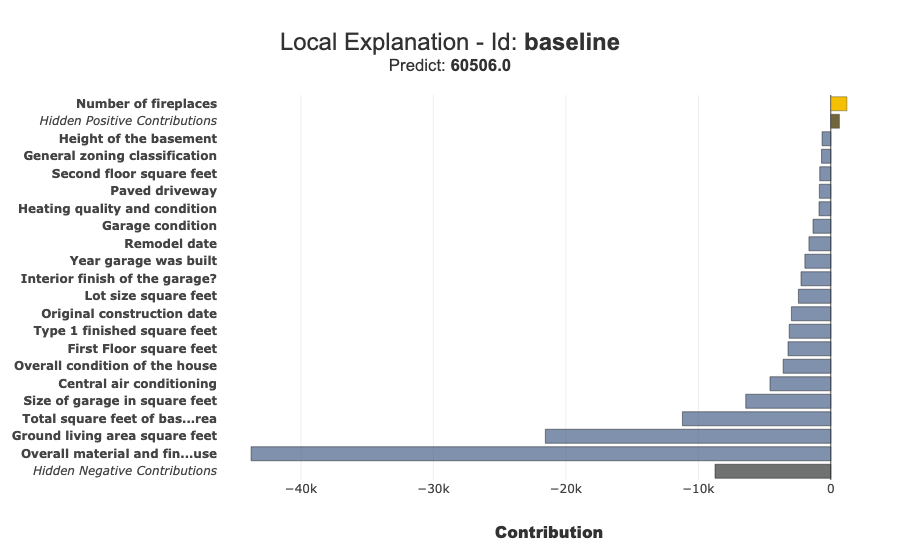

In [6]:
pair_raw = pd.concat([base_row, scenario_row], axis=0)
pair_raw.index = ["baseline", "what_if"]

pair_encoded = preprocessing.transform(pair_raw)

pair_pred_df = pd.DataFrame(
    model.predict(pair_encoded),
    index=pair_raw.index,
    columns=[target_name],
)

xpl_pair = SmartExplainer(
    model=model,
    preprocessing=preprocessing,
    features_dict=house_dict,
    title_story="Baseline vs what-if",
)
xpl_pair.compile(x=pair_encoded, y_pred=pair_pred_df, additional_data=pair_raw)

xpl_pair.plot.local_plot(index="baseline", yaxis_max_label=10)


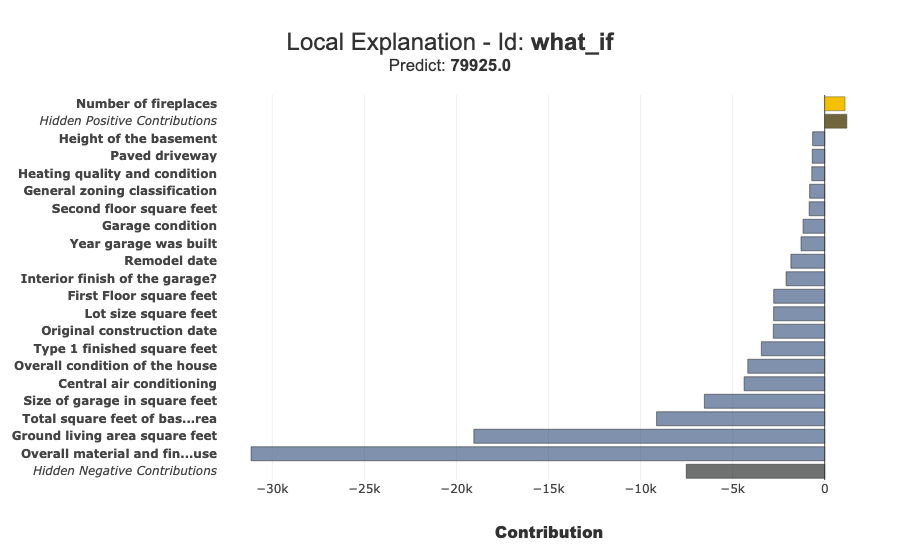

In [7]:
xpl_pair.plot.local_plot(index="what_if")

## 6. Practical recourse checklist

- Prioritize actionable variables (not fixed variables).
- Add business feasibility constraints (budget, timelines).
- Compare multiple scenarios, not just one.
- Confirm robustness on a set of individuals before production.